In [1]:
!pip install pandasql -q

  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import pandasql as ps
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)

print("✅ All libraries imported!")

✅ All libraries imported!


In [4]:
df = pd.read_excel('/content/Finance Stocks.xlsx', sheet_name='Transaction')

print(f"✅ File loaded!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ File loaded!
   Rows    : 6,000
   Columns : 21


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [5]:
df.head()

,Transaction ID,Date,Time,Ticker,Company Sector,Exchange,Transaction Type,Order Type,Account Type,Broker,Quantity,Price Per Share,Total Value,Commission Fee,Net Amount,Currency,Settlement Days,Status,Year,Month,Day Name
0,TXN000001,2022-10-13,14:06:00,AMZN,Consumer,NASDAQ,Short,Market,Margin,E*TRADE,13,"3,397.35","44,165.55",2.45,"44,163.10",USD,1,Executed,2022,Oct,Thu
1,TXN000002,2024-05-09,10:28:00,GS,Finance,NYSE,Buy,Stop,Retirement (IRA),TD Ameritrade,120,389.29,"46,714.80",5.61,"46,720.41",USD,3,Executed,2024,May,Thu
2,TXN000003,2023-11-21,09:05:00,XOM,Energy,NYSE,Sell,Stop-Limit,Retirement (IRA),Charles Schwab,80,89.67,"7,173.60",9.56,"7,164.04",USD,2,Executed,2023,Nov,Tue
3,TXN000004,2024-02-15,09:35:00,MSFT,Technology,NASDAQ,Cover,Stop,Margin,Charles Schwab,374,294.34,"110,083.16",5.36,"110,088.52",USD,3,Executed,2024,Feb,Thu
4,TXN000005,2022-06-13,15:14:00,GOOGL,Technology,NASDAQ,Sell,Market,401k,Charles Schwab,24,"2,821.00","67,704.00",7.72,"67,696.28",USD,2,Executed,2022,Jun,Mon


In [6]:
print(f"{'Column':<25} {'DataType':<15} {'Nulls'}")
print("-" * 50)
for col in df.columns:
    null_count = df[col].isnull().sum()
    print(f"{col:<25} {str(df[col].dtype):<15} {null_count}")

Column                    DataType        Nulls
--------------------------------------------------
Transaction ID            object          0
Date                      object          0
Time                      object          0
Ticker                    object          0
Company Sector            object          0
Exchange                  object          0
Transaction Type          object          0
Order Type                object          0
Account Type              object          0
Broker                    object          0
Quantity                  int64           0
Price Per Share           float64         0
Total Value               float64         0
Commission Fee            float64         0
Net Amount                float64         0
Currency                  object          0
Settlement Days           int64           0
Status                    object          0
Year                      int64           0
Month                     object          0
Day Name             

In [7]:
num_cols = ['Quantity', 'Price Per Share', 'Total Value',
            'Commission Fee', 'Net Amount']

df[num_cols].describe().round(2)

,Quantity,Price Per Share,Total Value,Commission Fee,Net Amount
count,"6,000.00","6,000.00","6,000.00","6,000.00","6,000.00"
mean,249.29,596.76,"149,351.35",4.95,"149,351.40"
std,144.22,978.06,"298,955.24",2.88,"298,955.26"
min,1.00,40.27,60.07,0.00,51.69
25%,125.00,135.23,"17,121.64",2.41,"17,125.20"
50%,248.00,163.86,"43,049.06",4.94,"43,044.64"
75%,376.00,402.95,"110,092.36",7.44,"110,098.57"
max,500.00,"3,555.42","1,739,885.00",9.99,"1,739,893.01"


In [8]:
print("Transaction Types :", df['Transaction Type'].unique())
print("Order Types       :", df['Order Type'].unique())
print("Exchanges         :", df['Exchange'].unique())
print("Status Values     :", df['Status'].unique())
print("Total Tickers     :", df['Ticker'].nunique())
print("Total Brokers     :", df['Broker'].nunique())

Transaction Types : ['Short' 'Buy' 'Sell' 'Cover']
Order Types       : ['Market' 'Stop' 'Stop-Limit' 'Limit']
Exchanges         : ['NASDAQ' 'NYSE']
Status Values     : ['Executed' 'Pending' 'Cancelled']
Total Tickers     : 16
Total Brokers     : 6


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

print(f"✅ Date column fixed!")
print(f"   Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"   Data type  : {df['Date'].dtype}")

✅ Date column fixed!
   Date range : 2022-01-01  →  2024-12-31
   Data type  : datetime64[ns]


In [10]:
df['Year']       = df['Date'].dt.year
df['Month_Num']  = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter']    = df['Date'].dt.quarter.apply(lambda x: f'Q{x}')
df['Day_Name']   = df['Date'].dt.day_name()

print("✅ Helper columns added!")
print(df[['Date','Year','Month_Num','Month_Name','Quarter','Day_Name']].head())

✅ Helper columns added!
        Date  Year  Month_Num Month_Name Quarter  Day_Name
0 2022-10-13  2022         10        Oct      Q4  Thursday
1 2024-05-09  2024          5        May      Q2  Thursday
2 2023-11-21  2023         11        Nov      Q4   Tuesday
3 2024-02-15  2024          2        Feb      Q1  Thursday
4 2022-06-13  2022          6        Jun      Q2    Monday


In [11]:
df['Commission_Rate_Pct'] = (
    df['Commission Fee'] / df['Total Value'] * 100
).round(4)

df['Trade_Size'] = pd.cut(
    df['Total Value'],
    bins   = [0, 10000, 50000, float('inf')],
    labels = ['Small (<10K)', 'Medium (10K-50K)', 'Large (>50K)']
)

print("✅ Calculated columns added!")
print()
print("Trade Size distribution:")
print(df['Trade_Size'].value_counts())

✅ Calculated columns added!

Trade Size distribution:
Trade_Size
Large (>50K)        2743
Medium (10K-50K)    2400
Small (<10K)         857
Name: count, dtype: int64


In [12]:
print(f"Total columns now : {df.shape[1]}")
print(f"New columns added : Year, Month_Num, Month_Name, Quarter, Day_Name, Commission_Rate_Pct, Trade_Size")
print()
print(df.dtypes.tail(8))

Total columns now : 27
New columns added : Year, Month_Num, Month_Name, Quarter, Day_Name, Commission_Rate_Pct, Trade_Size

Month                    object
Day Name                 object
Month_Num                 int32
Month_Name               object
Quarter                  object
Day_Name                 object
Commission_Rate_Pct     float64
Trade_Size             category
dtype: object


In [13]:
conn = sqlite3.connect(':memory:')

df.to_sql('transactions', conn, index=False, if_exists='replace')

verify = pd.read_sql("SELECT COUNT(*) AS total_rows FROM transactions", conn)
print("✅ SQLite database created!")
print(f"   Table name : transactions")
print(f"   Total rows : {verify['total_rows'][0]:,}")

✅ SQLite database created!
   Table name : transactions
   Total rows : 6,000


In [14]:
query1 = """
SELECT
    Ticker,
    [Company Sector]                    AS Sector,
    COUNT(*)                            AS Total_Transactions,
    ROUND(SUM([Total Value]), 2)        AS Total_Trade_Value,
    ROUND(AVG([Price Per Share]), 2)    AS Avg_Price_Per_Share,
    ROUND(SUM([Commission Fee]), 2)     AS Total_Commission
FROM transactions
WHERE Status = 'Executed'
GROUP BY Ticker, [Company Sector]
ORDER BY Total_Trade_Value DESC
"""

result1 = pd.read_sql(query1, conn)
result1

,Ticker,Sector,Total_Transactions,Total_Trade_Value,Avg_Price_Per_Share,Total_Commission
0,AMZN,Consumer,335,"293,661,576.55","3,402.01","1,657.77"
1,GOOGL,Technology,324,"230,285,688.46","2,799.07","1,619.44"
2,TSLA,Automotive,334,"64,981,458.45",800.39,"1,598.14"
3,SPY,ETF,301,"30,430,995.70",439.99,"1,472.65"
4,QQQ,ETF,330,"30,055,725.76",380.24,"1,634.06"
5,GS,Finance,326,"29,199,210.98",380.24,"1,598.97"
6,MSFT,Technology,317,"23,127,667.16",290.40,"1,651.06"
7,JNJ,Healthcare,345,"14,512,042.42",169.98,"1,706.90"
8,CVX,Energy,333,"13,771,245.79",159.91,"1,602.33"
9,AAPL,Technology,323,"12,744,239.48",150.02,"1,746.83"


In [15]:
query2 = """
SELECT
    Ticker,
    [Transaction Type]              AS Transaction_Type,
    COUNT(*)                        AS Trade_Count,
    ROUND(SUM([Total Value]), 2)    AS Total_Value,
    ROUND(AVG([Total Value]), 2)    AS Avg_Trade_Value,
    ROUND(SUM(Quantity), 0)         AS Total_Shares
FROM transactions
WHERE Status = 'Executed'
  AND [Transaction Type] IN ('Buy', 'Sell')
GROUP BY Ticker, [Transaction Type]
ORDER BY Ticker ASC, [Transaction Type] ASC
"""

result2 = pd.read_sql(query2, conn)
result2

,Ticker,Transaction_Type,Trade_Count,Total_Value,Avg_Trade_Value,Total_Shares
0,AAPL,Buy,85,"3,444,790.03","40,526.94","22,908.00"
1,AAPL,Sell,73,"2,796,299.19","38,305.47","18,618.00"
2,AMZN,Buy,78,"67,557,692.30","866,124.26","19,806.00"
3,AMZN,Sell,84,"70,777,448.17","842,588.67","20,702.00"
4,BAC,Buy,81,"798,916.06","9,863.16","19,019.00"
5,BAC,Sell,75,"866,722.72","11,556.30","20,592.00"
6,CVX,Buy,91,"3,812,273.94","41,893.12","23,853.00"
7,CVX,Sell,77,"3,461,925.06","44,960.07","21,670.00"
8,GOOGL,Buy,79,"57,463,333.97","727,383.97","20,448.00"
9,GOOGL,Sell,90,"63,595,067.74","706,611.86","22,707.00"


In [16]:
query3 = """
SELECT
    Year,
    Month_Num,
    Month_Name,
    COUNT(*)                        AS Total_Trades,
    ROUND(SUM([Total Value]), 2)    AS Monthly_Trade_Value,
    ROUND(AVG([Total Value]), 2)    AS Avg_Trade_Value
FROM transactions
WHERE Status = 'Executed'
GROUP BY Year, Month_Num, Month_Name
ORDER BY Year ASC, Month_Num ASC
"""

result3 = pd.read_sql(query3, conn)
print(result3.to_string(index=False))

 Year  Month_Num Month_Name  Total_Trades  Monthly_Trade_Value  Avg_Trade_Value
 2022          1        Jan           148        24,240,762.98       163,788.94
 2022          2        Feb           139        17,719,564.52       127,478.88
 2022          3        Mar           144        18,684,516.08       129,753.58
 2022          4        Apr           155        20,295,922.61       130,941.44
 2022          5        May           159        21,692,381.61       136,430.07
 2022          6        Jun           145        21,001,451.42       144,837.60
 2022          7        Jul           153        18,055,212.74       118,007.93
 2022          8        Aug           159        19,810,105.04       124,591.86
 2022          9        Sep           134        22,497,068.64       167,888.57
 2022         10        Oct           140        18,952,062.00       135,371.87
 2022         11        Nov           149        19,387,572.48       130,117.94
 2022         12        Dec           15

In [17]:
query4 = """
SELECT
    Broker,
    COUNT(*)                            AS Total_Trades,
    ROUND(SUM([Total Value]), 2)        AS Total_Trade_Value,
    ROUND(SUM([Commission Fee]), 2)     AS Total_Commission,
    ROUND(AVG([Commission Fee]), 4)     AS Avg_Commission_Per_Trade,
    ROUND(
        SUM([Commission Fee]) * 100.0
        / SUM([Total Value]), 4
    )                                   AS Commission_Rate_Pct
FROM transactions
WHERE Status = 'Executed'
GROUP BY Broker
ORDER BY Total_Commission DESC
"""

result4 = pd.read_sql(query4, conn)
result4

,Broker,Total_Trades,Total_Trade_Value,Total_Commission,Avg_Commission_Per_Trade,Commission_Rate_Pct
0,E*TRADE,925,"141,534,831.99","4,636.38",5.01,0.00
1,TD Ameritrade,847,"127,593,126.18","4,312.18",5.09,0.00
2,Charles Schwab,877,"132,163,031.83","4,309.14",4.91,0.00
3,Fidelity,860,"129,889,002.99","4,245.62",4.94,0.00
4,Interactive Brokers,866,"134,691,146.93","4,225.38",4.88,0.00
5,Robinhood,860,"120,488,590.11","4,184.48",4.87,0.00


In [18]:
query5 = """
SELECT
    Status,
    COUNT(*)                                AS Count,
    ROUND(
        COUNT(*) * 100.0
        / (SELECT COUNT(*) FROM transactions), 2
    )                                       AS Percentage,
    ROUND(SUM([Total Value]), 2)            AS Total_Value
FROM transactions
GROUP BY Status
ORDER BY Count DESC
"""

result5 = pd.read_sql(query5, conn)
result5

,Status,Count,Percentage,Total_Value
0,Executed,5235,87.25,"786,359,730.03"
1,Pending,512,8.53,"76,556,412.82"
2,Cancelled,253,4.22,"33,191,953.87"


In [19]:
query6 = """
SELECT
    [Company Sector]                    AS Sector,
    COUNT(DISTINCT Ticker)              AS Unique_Stocks,
    COUNT(*)                            AS Total_Trades,
    ROUND(SUM([Total Value]), 2)        AS Total_Value,
    ROUND(AVG([Price Per Share]), 2)    AS Avg_Price,
    ROUND(
        SUM([Total Value]) * 100.0
        / (SELECT SUM([Total Value]) FROM transactions
           WHERE Status = 'Executed'), 2
    )                                   AS Value_Share_Pct
FROM transactions
WHERE Status = 'Executed'
GROUP BY [Company Sector]
ORDER BY Total_Value DESC
"""

result6 = pd.read_sql(query6, conn)
result6

,Sector,Unique_Stocks,Total_Trades,Total_Value,Avg_Price,Value_Share_Pct
0,Consumer,1,335,"293,661,576.55","3,402.01",37.34
1,Technology,3,964,"266,157,595.10","1,086.53",33.85
2,Automotive,1,334,"64,981,458.45",800.39,8.26
3,ETF,2,631,"60,486,721.46",408.74,7.69
4,Finance,3,947,"43,457,208.23",191.05,5.53
5,Energy,2,649,"21,035,819.00",125.87,2.68
6,Healthcare,2,681,"18,937,364.53",110.76,2.41
7,Consumer Staples,2,694,"17,641,986.71",102.91,2.24


In [20]:
exec_df = df[df['Status'] == 'Executed'].copy()

print(f"Total rows      : {len(df):,}")
print(f"Executed rows   : {len(exec_df):,}")
print(f"Filtered out    : {len(df) - len(exec_df):,}")

Total rows      : 6,000
Executed rows   : 5,235
Filtered out    : 765


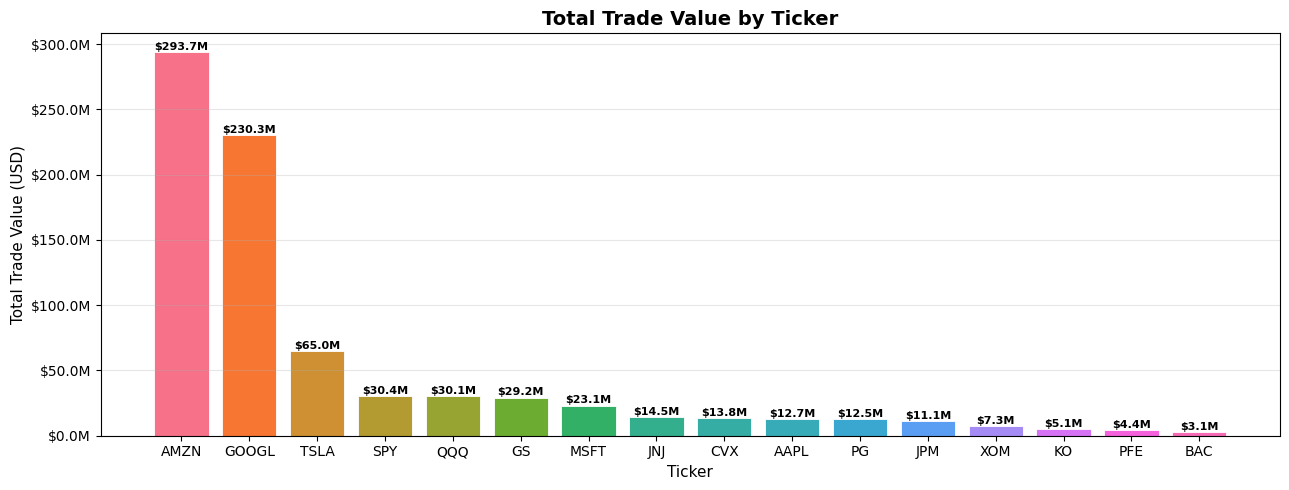

✅ Chart 1 saved!


In [21]:
ticker_val = (exec_df
    .groupby('Ticker')['Total Value']
    .sum()
    .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(13, 5))

colors = sns.color_palette("husl", len(ticker_val))
bars = ax.bar(ticker_val.index, ticker_val.values,
              color=colors, edgecolor='white', linewidth=0.6)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100000,
        f'${bar.get_height()/1e6:.1f}M',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

ax.set_title('Total Trade Value by Ticker', fontsize=14, fontweight='bold')
ax.set_xlabel('Ticker', fontsize=11)
ax.set_ylabel('Total Trade Value (USD)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_ticker_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

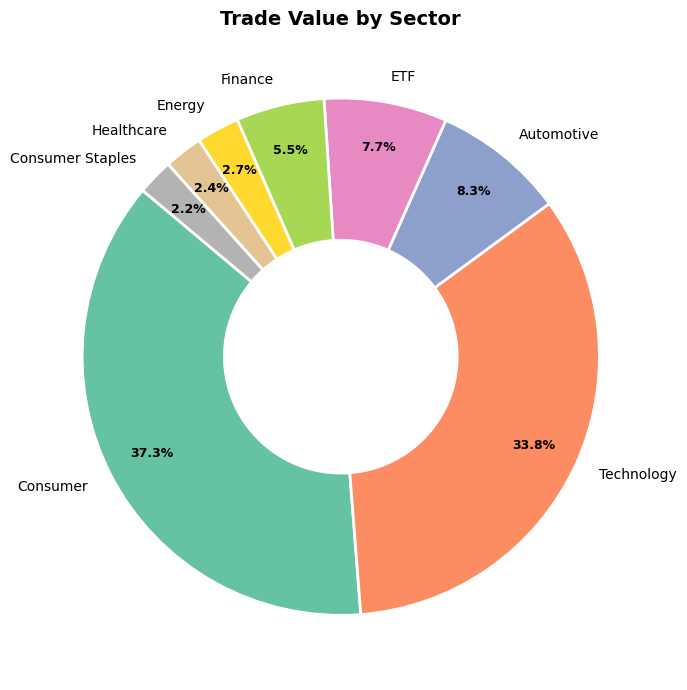

✅ Chart 2 saved!


In [22]:
sector_val = (exec_df
    .groupby('Company Sector')['Total Value']
    .sum()
    .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    sector_val.values,
    labels      = sector_val.index,
    autopct     = '%1.1f%%',
    startangle  = 140,
    pctdistance = 0.82,
    colors      = sns.color_palette("Set2", len(sector_val)),
    wedgeprops  = dict(width=0.55, edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

ax.set_title('Trade Value by Sector', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_sector_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

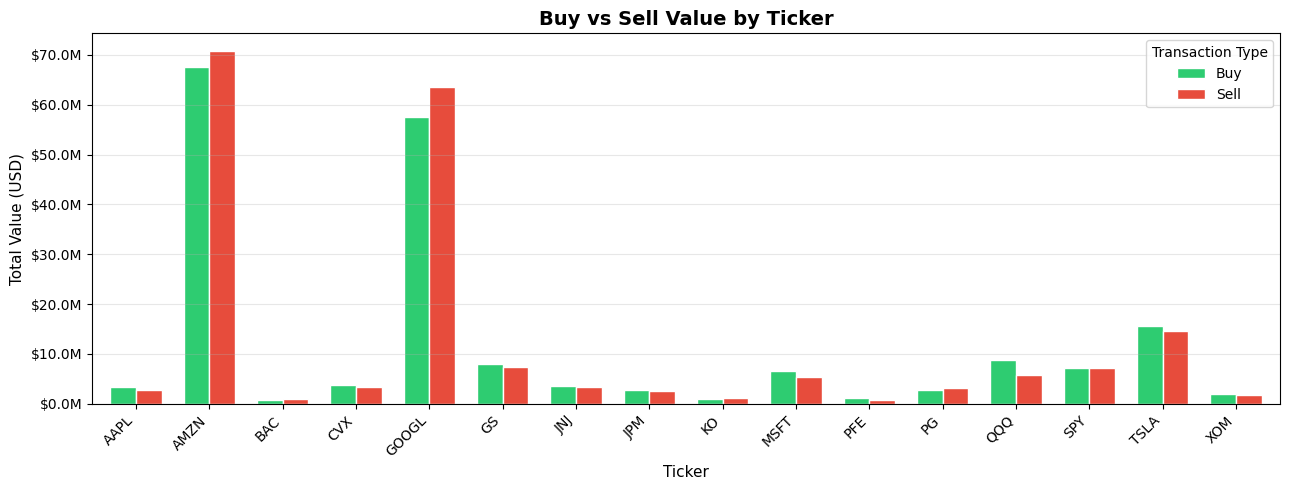

✅ Chart 3 saved!


In [23]:
buysell_df = exec_df[exec_df['Transaction Type'].isin(['Buy', 'Sell'])]

pivot_bs = buysell_df.pivot_table(
    index   = 'Ticker',
    columns = 'Transaction Type',
    values  = 'Total Value',
    aggfunc = 'sum'
).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))

pivot_bs.plot(
    kind      = 'bar',
    ax        = ax,
    color     = ['#2ecc71', '#e74c3c'],
    edgecolor = 'white',
    width     = 0.7
)

ax.set_title('Buy vs Sell Value by Ticker', fontsize=14, fontweight='bold')
ax.set_xlabel('Ticker', fontsize=11)
ax.set_ylabel('Total Value (USD)', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)
ax.legend(title='Transaction Type', fontsize=10)
ax.set_xticklabels(pivot_bs.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart3_buy_vs_sell.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

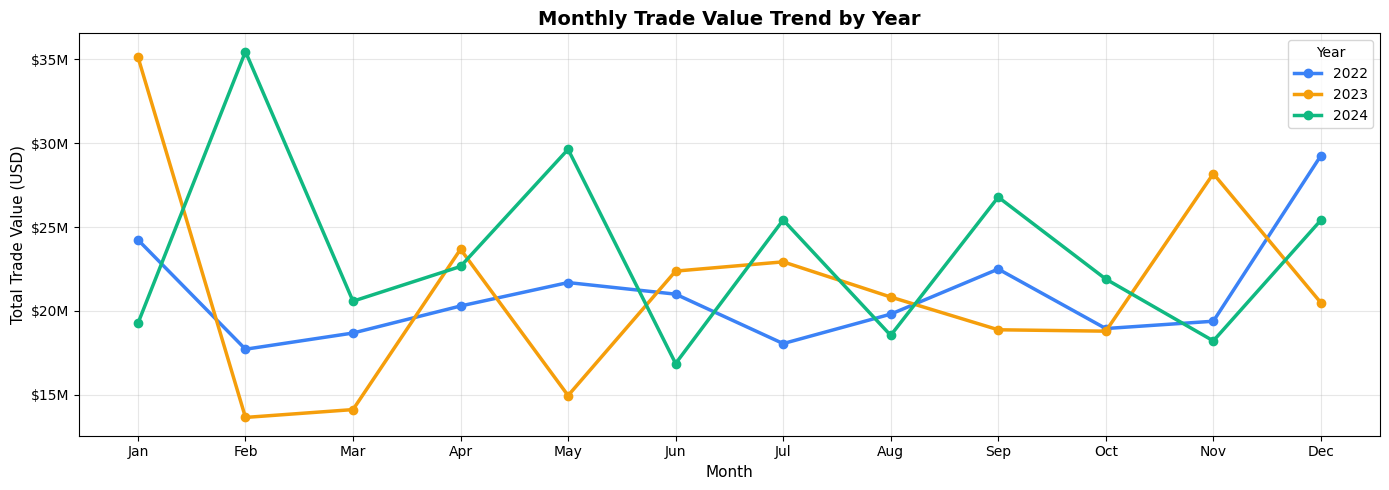

✅ Chart 4 saved!


In [24]:
monthly = (exec_df
    .groupby(['Year', 'Month_Num', 'Month_Name'])['Total Value']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month_Num']))

fig, ax = plt.subplots(figsize=(14, 5))

year_colors = {2022: '#3b82f6', 2023: '#f59e0b', 2024: '#10b981'}

for year, group in monthly.groupby('Year'):
    ax.plot(group['Month_Num'], group['Total Value'],
            marker='o', linewidth=2.5, markersize=6,
            label=str(year), color=year_colors[year])

ax.set_title('Monthly Trade Value Trend by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Trade Value (USD)', fontsize=11)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)
ax.legend(title='Year', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

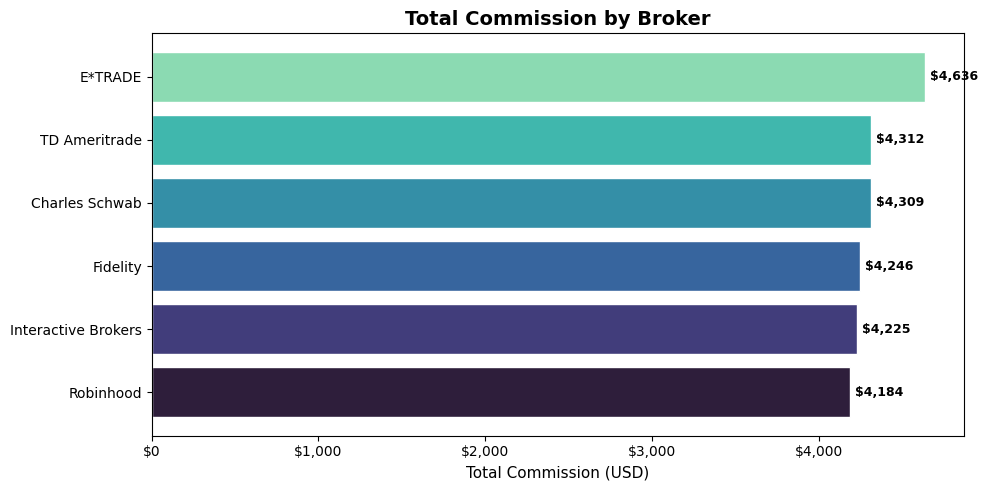

✅ Chart 5 saved!


In [26]:
broker_comm = (exec_df
    .groupby('Broker')['Commission Fee']
    .sum()
    .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))

colors = sns.color_palette("mako", len(broker_comm))
bars = ax.barh(broker_comm.index, broker_comm.values,
               color=colors, edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():,.0f}',
        va='center', fontsize=9, fontweight='bold'
    )

ax.set_title('Total Commission by Broker', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Commission (USD)', fontsize=11)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig('chart5_broker_commission.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

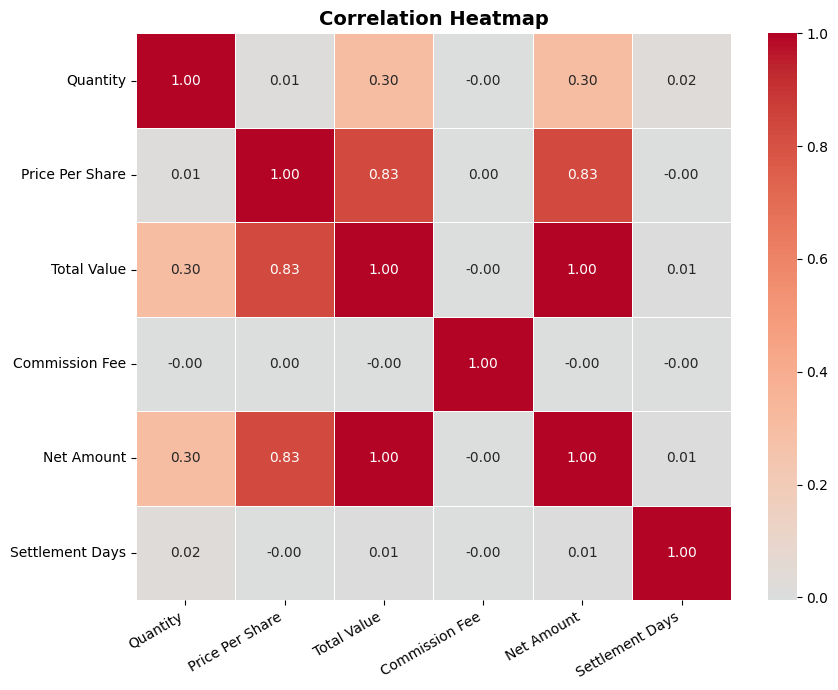

How to read:
  1.0  = perfect positive correlation
 -1.0  = perfect negative correlation
  0.0  = no correlation


In [27]:
num_cols = ['Quantity', 'Price Per Share', 'Total Value',
            'Commission Fee', 'Net Amount', 'Settlement Days']

corr_matrix = exec_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'coolwarm',
    center     = 0,
    ax         = ax,
    linewidths = 0.5,
    annot_kws  = {'size': 10}
)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('chart6_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("How to read:")
print("  1.0  = perfect positive correlation")
print(" -1.0  = perfect negative correlation")
print("  0.0  = no correlation")

In [28]:
print("=" * 55)
print("   FINANCE STOCKS — ANALYSIS SUMMARY")
print("=" * 55)

total     = len(df)
executed  = len(exec_df)

print(f"\n  Total Transactions  : {total:,}")
print(f"  Executed            : {executed:,}  ({executed/total*100:.1f}%)")
print(f"  Pending             : {(df['Status']=='Pending').sum():,}")
print(f"  Cancelled           : {(df['Status']=='Cancelled').sum():,}")

print(f"\n  Total Trade Value   : ${exec_df['Total Value'].sum():,.2f}")
print(f"  Total Commission    : ${exec_df['Commission Fee'].sum():,.2f}")
print(f"  Avg Price/Share     : ${exec_df['Price Per Share'].mean():,.2f}")
print(f"  Avg Trade Value     : ${exec_df['Total Value'].mean():,.2f}")

top_ticker = exec_df.groupby('Ticker')['Total Value'].sum().idxmax()
top_sector = exec_df.groupby('Company Sector')['Total Value'].sum().idxmax()
top_broker = exec_df.groupby('Broker')['Commission Fee'].sum().idxmax()

print(f"\n  Top Ticker          : {top_ticker}")
print(f"  Top Sector          : {top_sector}")
print(f"  Costliest Broker    : {top_broker}")
print(f"  Date Range          : {df['Date'].min().date()} → {df['Date'].max().date()}")
print("\n" + "=" * 55)
print("  ✅ Analysis Complete! Ready for Portfolio.")
print("=" * 55)

   FINANCE STOCKS — ANALYSIS SUMMARY

  Total Transactions  : 6,000
  Executed            : 5,235  (87.2%)
  Pending             : 512
  Cancelled           : 253

  Total Trade Value   : $786,359,730.03
  Total Commission    : $25,913.18
  Avg Price/Share     : $596.33
  Avg Trade Value     : $150,211.98

  Top Ticker          : AMZN
  Top Sector          : Consumer
  Costliest Broker    : E*TRADE
  Date Range          : 2022-01-01 → 2024-12-31

  ✅ Analysis Complete! Ready for Portfolio.
